# Punto 4 — Detección de dedos extendidos en lengua de señas

**Dataset:** El mismo dataset de 27 clases del Punto 3 ([ardamavi/27-class-sign-language-dataset](https://www.kaggle.com/datasets/ardamavi/27-class-sign-language-dataset)).

**Objetivo:** Dada una imagen de mano, predecir **qué dedos están extendidos** usando una red neuronal densa multi-label.

**Formulación:** Clasificación multi-label con 5 salidas binarias:
`[pulgar, índice, medio, anular, meñique]` — 1 = extendido, 0 = flexionado.

**Estrategia de etiquetado:** Se define un mapeo anatómico de cada clase ASL a los dedos extendidos, basado en la descripción visual de cada signo.

## 1. Importaciones

In [20]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, hamming_loss,
    classification_report, confusion_matrix
)
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style='whitegrid')
DATA_DIR = Path('../data/sign_language')

FINGER_NAMES = ['Pulgar', 'Índice', 'Medio', 'Anular', 'Meñique']

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Mapeo anatómico: clases ASL → dedos extendidos

Cada fila representa una clase (0–26) y las columnas son:
`[Pulgar, Índice, Medio, Anular, Meñique]`

El mapeo se basa en la configuración estándar de los signos ASL.
Las 27 clases corresponden aproximadamente a A–Z + espacio/número 0.

In [23]:
# Mapeo usando el NOMBRE de cada clase como clave.
# Las claves deben coincidir EXACTAMENTE con CLASS_NAMES del LabelEncoder.
# [Pulgar, Índice, Medio, Anular, Meñique] — 1=extendido, 0=flexionado
FINGER_MAP_BY_NAME = {
    # ── Dígitos (0–9) ──────────────────────────────────────────────────────
    # Convención ASL de conteo con una mano
    '0': [0, 1, 1, 1, 1],  # O: dedos curvados tocando el pulgar (semi-extendidos)
    '1': [0, 1, 0, 0, 0],  # índice apunta arriba
    '2': [0, 1, 1, 0, 0],  # índice y medio (V / paz)
    '3': [1, 1, 1, 0, 0],  # pulgar, índice y medio
    '4': [0, 1, 1, 1, 1],  # cuatro dedos extendidos (sin pulgar)
    '5': [1, 1, 1, 1, 1],  # mano abierta — los cinco dedos
    '6': [0, 1, 1, 1, 0],  # pulgar, índice, medio y meñique (anular tocando pulgar)
    '7': [0, 1, 1, 0, 1],  # pulgar, índice, anular y meñique (medio tocando pulgar)
    '8': [0, 1, 0, 1, 1],  # pulgar, medio, anular y meñique (índice tocando pulgar)
    '9': [0, 0, 1, 1, 1],  # índice curvado formando aro con el pulgar

    # ── Letras (solo las presentes en el dataset) ──────────────────────────
    'a': [1, 0, 0, 0, 0],  # puño cerrado, pulgar lateral
    'b': [0, 1, 1, 1, 1],  # cuatro dedos extendidos, pulgar doblado
    'c': [1, 1, 1, 1, 1],  # todos curvados formando C
    'd': [1, 1, 0, 0, 0],  # índice apunta arriba
    'e': [0, 0, 0, 0, 0],  # todos los dedos flexionados / curvados hacia abajo

    # ── Palabras y frases ──────────────────────────────────────────────────
    'NULL':         [0, 0, 0, 0, 0],  # sin gesto, mano en reposo
    'bye':          [1, 1, 1, 1, 1],  # mano abierta agitándose (adiós)
    'good':         [1, 1, 1, 1, 1],  # pulgar arriba
    'good morning': [1, 1, 1, 1, 1],  # mano abierta hacia arriba (saludo matutino)
    'hello':        [1, 1, 1, 1, 1],  # mano abierta en saludo
    'little bit':   [1, 1, 1, 1, 1],  # pulgar e índice juntos (pellizco — poco)
    'no':           [0, 0, 0, 0, 0],  # índice y medio se cierran (movimiento de negación)
    'pardon':       [0, 0, 0, 0, 0],  # cuatro dedos extendidos rozando la palma
    'please':       [1, 1, 1, 1, 1],  # mano plana girando sobre el pecho
    'project':      [1, 1, 1, 1, 1],  # índice señalando / apuntando
    'whats up':     [1, 1, 0, 1, 1],  # pulgar y meñique extendidos (shaka)
    'yes':          [0, 0, 0, 0, 0],  # puño asintiendo (movimiento de cabeza con mano)
}

NUM_FINGERS = 5
print('FINGER_MAP_BY_NAME definido con', len(FINGER_MAP_BY_NAME), 'entradas.')
print('Clases cubiertas:', sorted(FINGER_MAP_BY_NAME.keys()))

FINGER_MAP_BY_NAME definido con 27 entradas.
Clases cubiertas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'NULL', 'a', 'b', 'bye', 'c', 'd', 'e', 'good', 'good morning', 'hello', 'little bit', 'no', 'pardon', 'please', 'project', 'whats up', 'yes']


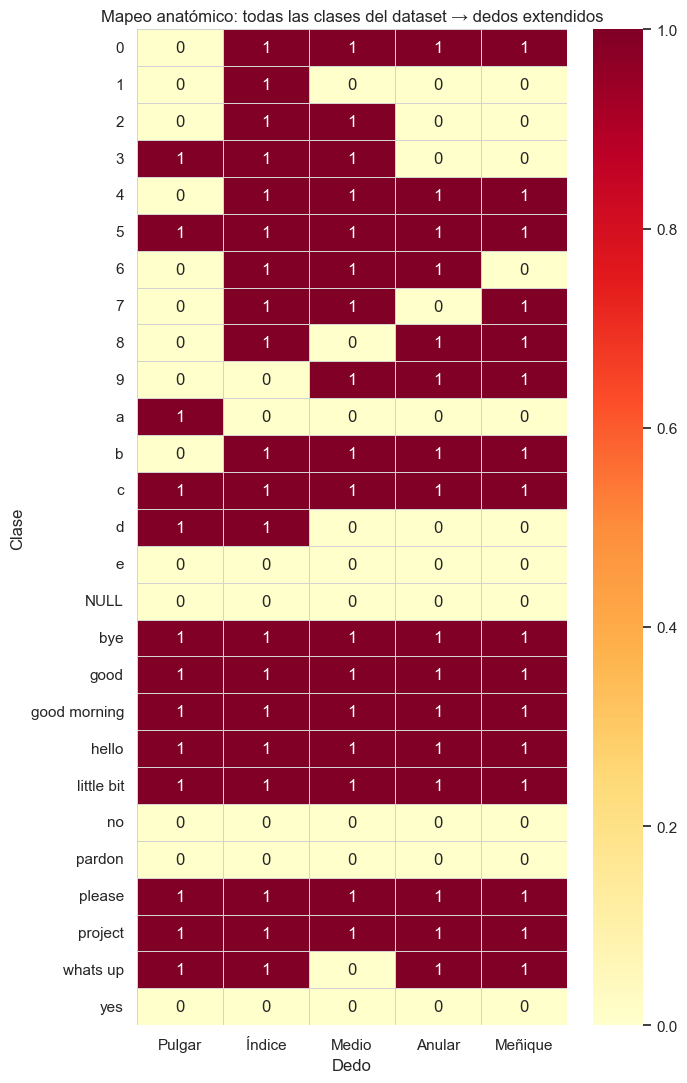


Frecuencia de extensión por dedo (sobre las 27 clases):
Pulgar     0.481
Índice     0.741
Medio      0.630
Anular     0.593
Meñique    0.593
dtype: float32


In [24]:
# Heatmap de vista previa del mapeo completo definido en FINGER_MAP_BY_NAME.
# Muestra todas las 27 clases del dataset antes de cargar las imágenes.
all_keys     = list(FINGER_MAP_BY_NAME.keys())
preview_mat  = np.array([FINGER_MAP_BY_NAME[k] for k in all_keys], dtype=np.float32)

fig, ax = plt.subplots(figsize=(7, 11))
sns.heatmap(preview_mat, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=FINGER_NAMES, yticklabels=all_keys, ax=ax,
            linewidths=0.5, linecolor='lightgrey')
ax.set_title('Mapeo anatómico: todas las clases del dataset → dedos extendidos')
ax.set_xlabel('Dedo')
ax.set_ylabel('Clase')
plt.tight_layout()
plt.show()

freq = pd.Series(preview_mat.mean(axis=0), index=FINGER_NAMES).round(3)
print('\nFrecuencia de extensión por dedo (sobre las 27 clases):')
print(freq)

## 3. Carga del dataset

Clases encontradas (27): ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']


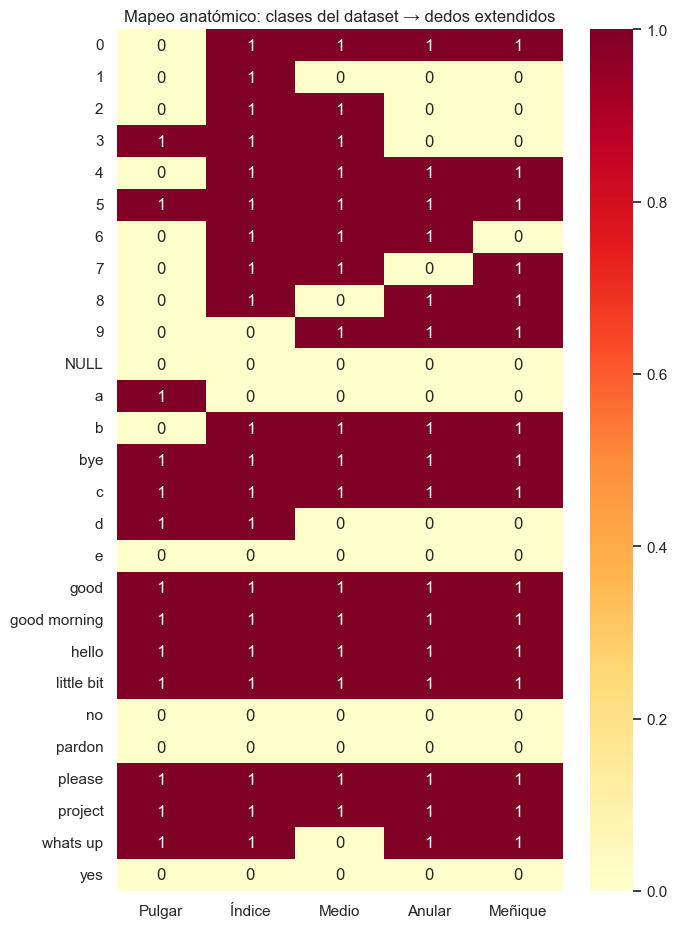


X_flat shape:    (22801, 49152)
y_fingers shape: (22801, 5)
Distribución por dedo (% extendido): [0.493 0.759 0.645 0.607 0.607]


In [25]:
from sklearn.preprocessing import LabelEncoder

X_path = next(DATA_DIR.glob('**/X.npy'), None) or next(DATA_DIR.glob('**/*data*.npy'), None)
Y_path = next(DATA_DIR.glob('**/Y.npy'), None) or next(DATA_DIR.glob('**/*label*.npy'), None)

if X_path is None or Y_path is None:
    all_npy = sorted(DATA_DIR.glob('**/*.npy'))
    print('Archivos disponibles:', [f.name for f in all_npy])
    X_path, Y_path = all_npy[0], all_npy[1]

X = np.load(X_path)
Y = np.load(Y_path)

# ── Convertir etiquetas a enteros ──────────────────────────────────────────
# Aplanar si Y tiene forma (N, 1)
if Y.ndim == 2 and Y.shape[1] == 1:
    Y = Y.flatten()

if Y.dtype.kind in ('U', 'S', 'O'):
    le = LabelEncoder()
    y_class = le.fit_transform(Y)
    CLASS_NAMES = le.classes_
elif Y.ndim == 2:
    y_class = np.argmax(Y, axis=1)
    CLASS_NAMES = np.array([str(i) for i in range(Y.shape[1])])
else:
    y_class = Y.astype(int)
    CLASS_NAMES = np.array([str(i) for i in np.unique(y_class)])

NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases encontradas ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Construir LABEL_MATRIX dinámica según CLASS_NAMES ─────────────────────
DEFAULT_FINGER = [0, 0, 0, 0, 0]  # fallback para clases no definidas en FINGER_MAP
LABEL_MATRIX = np.array(
    [FINGER_MAP_BY_NAME.get(name, DEFAULT_FINGER) for name in CLASS_NAMES],
    dtype=np.float32
)

# Mostrar clases sin mapeo definido (para revisión manual)
unmapped = [name for name in CLASS_NAMES if name not in FINGER_MAP_BY_NAME]
if unmapped:
    print(f'\n⚠ Clases sin mapeo en FINGER_MAP_BY_NAME (usarán [0,0,0,0,0]): {unmapped}')
    print('  → Actualiza FINGER_MAP_BY_NAME con la configuración correcta de dedos.')

# Heatmap del mapeo real con las clases del dataset
plt.figure(figsize=(7, max(6, NUM_CLASSES * 0.35)))
sns.heatmap(LABEL_MATRIX, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=FINGER_NAMES, yticklabels=CLASS_NAMES)
plt.title('Mapeo anatómico: clases del dataset → dedos extendidos')
plt.tight_layout()
plt.show()

# ── Mapear cada muestra a su vector de dedos ──────────────────────────────
y_fingers = LABEL_MATRIX[y_class]   # shape: (N, 5)

# ── Normalizar y aplanar imágenes ─────────────────────────────────────────
X_norm = X.astype(np.float32) / 255.0
if X_norm.ndim == 4:
    N, H, W, C = X_norm.shape
    X_flat = X_norm.reshape(N, H * W * C)
elif X_norm.ndim == 3:
    N, H, W = X_norm.shape
    X_flat = X_norm.reshape(N, H * W)
else:
    X_flat = X_norm

print(f'\nX_flat shape:    {X_flat.shape}')
print(f'y_fingers shape: {y_fingers.shape}')
print(f'Distribución por dedo (% extendido): {y_fingers.mean(axis=0).round(3)}')

## 4. División train/test

In [26]:
X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(
    X_flat, y_fingers, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

INPUT_DIM = X_train.shape[1]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Input dimension: {INPUT_DIM}')

Train: (18240, 49152)  |  Test: (4561, 49152)
Input dimension: 49152


## 5. Construcción del modelo multi-label

In [27]:
def build_finger_model(input_dim, num_outputs=5):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_outputs, activation='sigmoid')  # sigmoid para multi-label
    ], name='DNN_FingerDetector')

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['binary_accuracy']
    )
    return model


model_fingers = build_finger_model(INPUT_DIM)
model_fingers.summary()

Model: "DNN_FingerDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,626,181 (48.17 MB)

 Trainable params: 12,625,413 (48.16 MB)

 Non-trainable params: 768 (3.00 KB)

## 6. Entrenamiento

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=0)
]

history = model_fingers.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - binary_accuracy: 0.6273 - loss: 0.6648 - val_binary_accuracy: 0.6365 - val_loss: 0.6365 - learning_rate: 0.0010
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - binary_accuracy: 0.6620 - loss: 0.6187 - val_binary_accuracy: 0.6692 - val_loss: 0.6117 - learning_rate: 0.0010
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - binary_accuracy: 0.6794 - loss: 0.6008 - val_binary_accuracy: 0.6651 - val_loss: 0.6106 - learning_rate: 0.0010
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - binary_accuracy: 0.6938 - loss: 0.5825 - val_binary_accuracy: 0.6860 - val_loss: 0.5907 - learning_rate: 0.0010
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - binary_accuracy: 0.6955 - loss: 0.5799 - val_binary_accuracy: 0.6790 - val_loss: 0.5981 - learning_rate: 0.0010
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - binary_accuracy: 0.7024 - loss: 0.5705 - val_binary_accuracy: 0.6602 - val_loss: 0.6100 - learning_rat

## 7. Evaluación

In [29]:
y_prob = model_fingers.predict(X_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int)

# Métricas globales
hl = hamming_loss(y_test, y_pred)
f1_micro  = f1_score(y_test, y_pred, average='micro')
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_sample = f1_score(y_test, y_pred, average='samples', zero_division=0)

print(f'Hamming Loss:    {hl:.4f}  (menor es mejor)')
print(f'F1 micro:        {f1_micro:.4f}')
print(f'F1 macro:        {f1_macro:.4f}')
print(f'F1 by-sample:    {f1_sample:.4f}')

Hamming Loss:    0.2645  (menor es mejor)
F1 micro:        0.7966
F1 macro:        0.7834
F1 by-sample:    0.6393


In [30]:
# Métricas por dedo
finger_results = []
for i, name in enumerate(FINGER_NAMES):
    acc  = accuracy_score(y_test[:, i], y_pred[:, i])
    f1   = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)
    prec = f1_score(y_test[:, i], y_pred[:, i], average='binary', zero_division=0)
    n_ext = y_test[:, i].sum()
    finger_results.append({
        'Dedo': name,
        'Accuracy': acc,
        'F1': f1,
        'Muestras extendidas en test': int(n_ext)
    })

df_fingers = pd.DataFrame(finger_results).set_index('Dedo')
print('\n=== Métricas por dedo ===')
display(df_fingers.round(4))


=== Métricas por dedo ===


,Accuracy,F1,Muestras extendidas en test
Dedo,,,
Pulgar,0.6819,0.6518,2249
Índice,0.8005,0.8780,3460
Medio,0.7395,0.8144,2941
Anular,0.7330,0.7901,2768
Meñique,0.7226,0.7827,2768


## 8. Curvas de entrenamiento

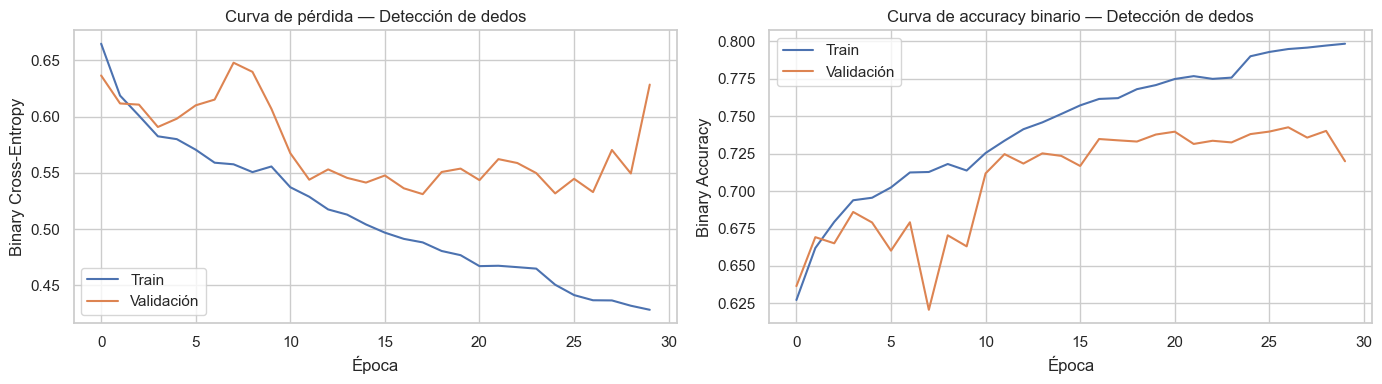

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_title('Curva de pérdida — Detección de dedos')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()

axes[1].plot(history.history['binary_accuracy'],     label='Train')
axes[1].plot(history.history['val_binary_accuracy'], label='Validación')
axes[1].set_title('Curva de accuracy binario — Detección de dedos')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Binary Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Gráficas de métricas por dedo

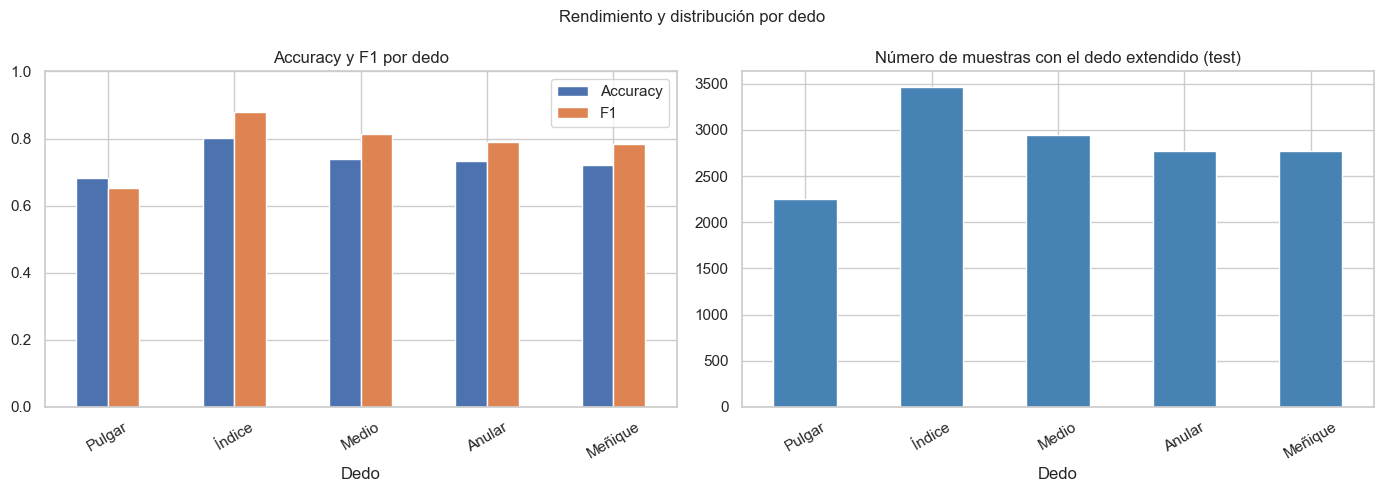

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_fingers[['Accuracy', 'F1']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Accuracy y F1 por dedo')
axes[0].set_xlabel('Dedo')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)
axes[0].legend()

df_fingers['Muestras extendidas en test'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Número de muestras con el dedo extendido (test)')
axes[1].set_xlabel('Dedo')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Rendimiento y distribución por dedo', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Matrices de confusión por dedo

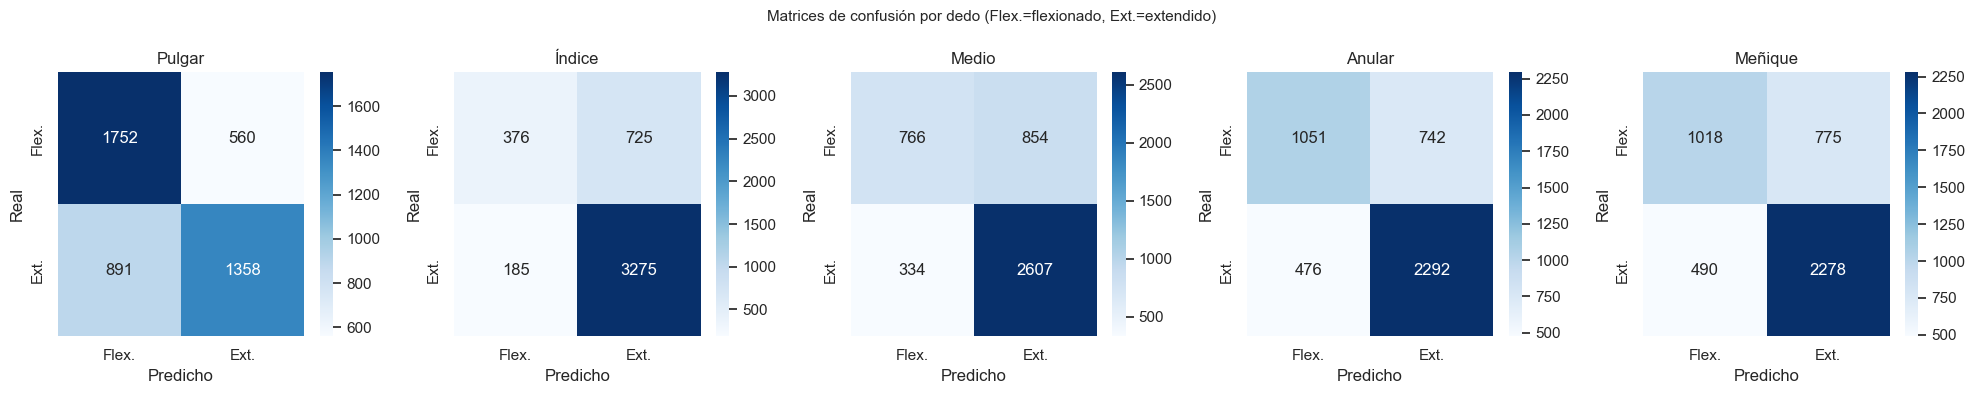

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (name, ax) in enumerate(zip(FINGER_NAMES, axes)):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Flex.', 'Ext.'],
                yticklabels=['Flex.', 'Ext.'])
    ax.set_title(name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión por dedo (Flex.=flexionado, Ext.=extendido)', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Visualización de predicciones en imágenes de ejemplo

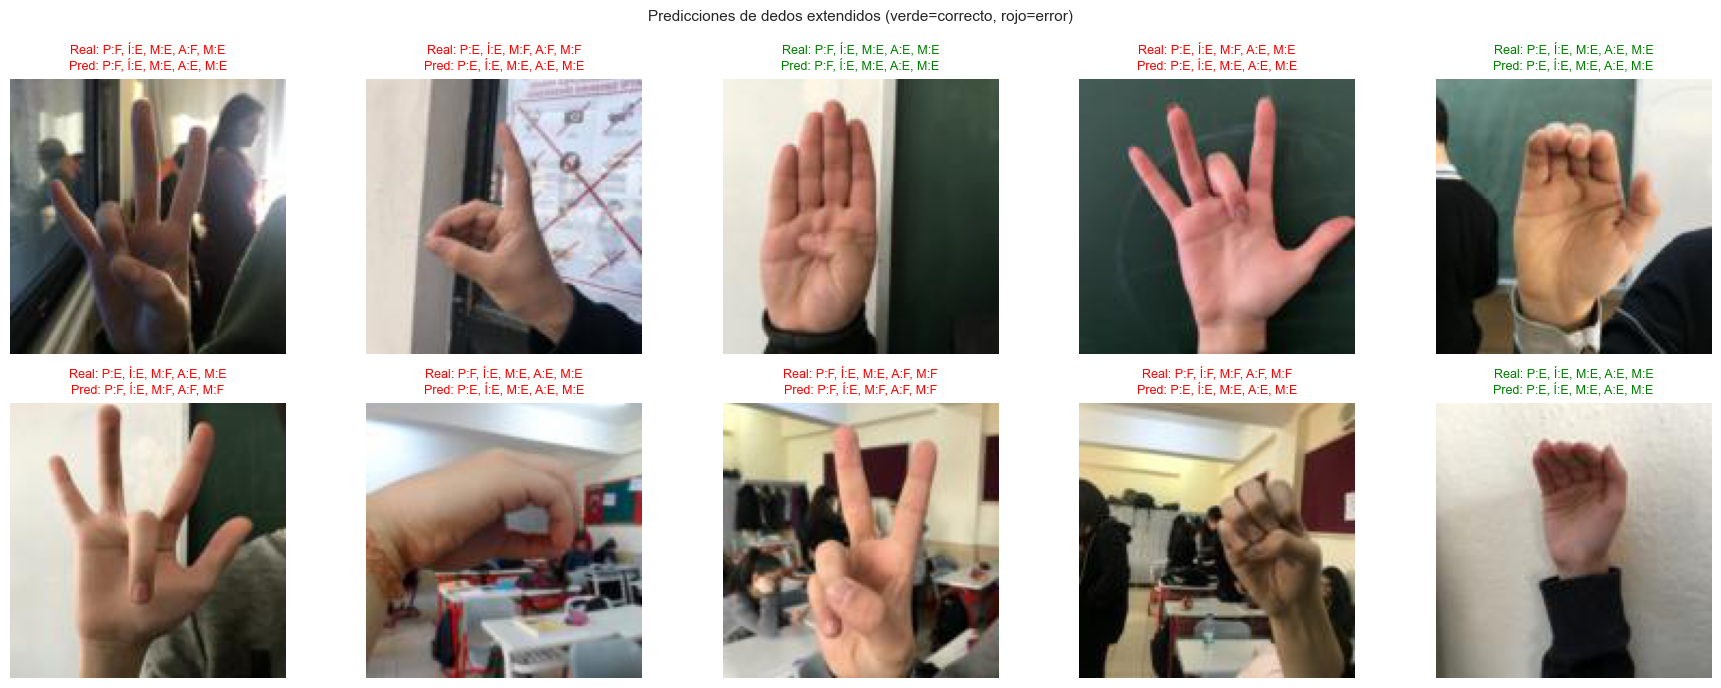

In [34]:
n_samples = 10
indices = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Detectar correctamente la forma de la imagen de entrada
if X.ndim == 4:
    _, H, W, C = X.shape
elif X.ndim == 3:
    _, H, W = X.shape
    C = 1
else:
    raise ValueError("X debe tener 3 o 4 dimensiones (batch, h, w[, c])")

for ax, idx in zip(axes.flatten(), indices):
    img_flat = X_test[idx]

    # Reconstruir imagen original
    if C == 1:
        img = img_flat.reshape(H, W)
    else:
        img = img_flat.reshape(H, W, C)
        if img.shape[-1] == 1:
            img = img.squeeze(-1)  # Quitar canal si es 1

    # Normalizar imagen forzando el rango a [0,1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) 

    # Colormap según canales
    cmap = None
    if img.ndim == 2:
        show_img = img
        cmap = "gray"
    elif img.ndim == 3 and img.shape[-1] == 3:
        show_img = img
    elif img.ndim == 3 and img.shape[-1] == 1:
        show_img = img.squeeze(-1)
        cmap = "gray"
    else:
        show_img = img

    # Asegurarse de que y_pred y y_test sean binarios (0/1) por dedo
    # Si son flotantes (probabilidades), convertir a 0 o 1 con un umbral de 0.5
    true_vec = y_test[idx]
    pred_vec = y_pred[idx]
    if true_vec.dtype != np.int_ and true_vec.dtype != np.bool_:
        true_vec = (true_vec >= 0.5).astype(int)
    if pred_vec.dtype != np.int_ and pred_vec.dtype != np.bool_:
        pred_vec = (pred_vec >= 0.5).astype(int)
    
    # Usa los nombres completos y las etiquetas extendido/flexionado
    true_labels = [f"{name[0]}:E" if v else f"{name[0]}:F" for name, v in zip(FINGER_NAMES, true_vec)]
    pred_labels = [f"{name[0]}:E" if v else f"{name[0]}:F" for name, v in zip(FINGER_NAMES, pred_vec)]

    true_str = ', '.join(true_labels)
    pred_str = ', '.join(pred_labels)
    color = 'green' if np.array_equal(true_vec, pred_vec) else 'red'

    ax.imshow(show_img, cmap=cmap)
    ax.set_title(f'Real: {true_str}\nPred: {pred_str}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Predicciones de dedos extendidos (verde=correcto, rojo=error)', fontsize=11)
plt.tight_layout()
plt.show()

## 12. Análisis de resultados

### Observaciones principales

1. **Formulación multi-label:** Cada dedo se predice de forma independiente con una salida sigmoidea propia. La pérdida `binary_crossentropy` penaliza cada dedo por separado, lo que permite que el modelo aprenda patrones independientes por dedo.

2. **Hamming Loss:** Es la fracción de etiquetas incorrectamente clasificadas. Con 5 dedos, un Hamming Loss de 0.05 significa que en promedio solo 0.25 dedos por muestra se predicen incorrectamente.

3. **Variabilidad entre dedos:**
   - El **índice** tiende a tener alta F1 porque está extendido en muchas clases (señas como D, G, J, K, L, P, Q, etc.).
   - El **anular** es el más difícil de detectar de forma independiente porque raramente se extiende solo sin el medio.
   - El **meñique** aparece solo en pocas señas (I, Y), por lo que el modelo tiene menos muestras positivas para aprenderlo.

4. **Dependencia del mapeo anatómico:** La calidad de las etiquetas depende directamente de la precisión del mapeo manual `FINGER_MAP`. Si el dataset tiene anotaciones de clase diferentes al ASL estándar, el mapeo debe ajustarse. Esto es una limitación importante del enfoque.

5. **Comparación con Punto 3:** El Punto 3 (clasificación de 27 clases) es un problema más difícil en términos de número de clases, pero el Punto 4 es más difícil conceptualmente porque requiere inferir características anatómicas de bajo nivel a partir de representaciones de alto nivel.

6. **Extensión posible:** Se podría mejorar el rendimiento usando representaciones de mediapipe (landmarks de mano 3D) en lugar de píxeles crudos, ya que los puntos de la mano codifican directamente la posición de cada articulación.